In [19]:
import numpy as np
import pandas as pd
import seaborn as sns

In [20]:
Data = pd.read_csv("coffee_shop_revenue.csv")

In [21]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [22]:
print(Data.isnull().sum())

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64


2. TÁCH X,Y

In [23]:
X = Data.drop(columns=['Daily_Revenue'])
y = Data['Daily_Revenue']


3. CHIA TRAIN/TEST

In [24]:
ratio = 0.8

split = int(len(X) * ratio)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


4. CHUẨN HÓA DỮ LIỆU

In [25]:

class ZScoreNormalizer:
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1   # tránh chia cho 0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
normalizer = ZScoreNormalizer()

X_train = normalizer.fit_transform(X_train)
X_test = normalizer.fit_transform(X_test)



5. LINEAR REGRESSION

In [26]:
class LinearRegression:

    def __init__(self, lr=0.01, epochs=10000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):

        m, n = X.shape

        self.w = np.zeros(n)
        self.b = 0

        for _ in range(self.epochs):

            y_pred = X @ self.w + self.b

            error = y_pred - y

            dw = (1/m) * X.T @ error
            db = (1/m) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):

        return X @ self.w + self.b

6. TRAIN

In [27]:
model = LinearRegression(
    lr=0.001,
    epochs=5000
)

model.fit(X_train, y_train)


7. PREDICT

In [28]:
y_pred = model.predict(X_test)

8. MAE, MSE, RMSE, R2

In [29]:
def MAE(y_true, y_pred):

    return np.mean(np.abs(y_true - y_pred))

def MSE(y_true, y_pred):

    return np.mean((y_true - y_pred)**2)

def RMSE(y_true, y_pred):

    return np.sqrt(MSE(y_true, y_pred))

def R2(y_true, y_pred):

    ss_res = np.sum((y_true - y_pred)**2)

    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    return 1 - ss_res/ss_tot

9. ĐÁNH GIÁ

In [30]:
print("MAE :", MAE(y_test, y_pred))
print("MSE :", MSE(y_test, y_pred))
print("RMSE:", RMSE(y_test, y_pred))
print("R²  :", R2(y_test, y_pred))

MAE : 254.18492867985205
MSE : 105180.14146995138
RMSE: 324.3148801241648
R²  : 0.8963751314428041


10. HỆ SỐ HỒI QUY

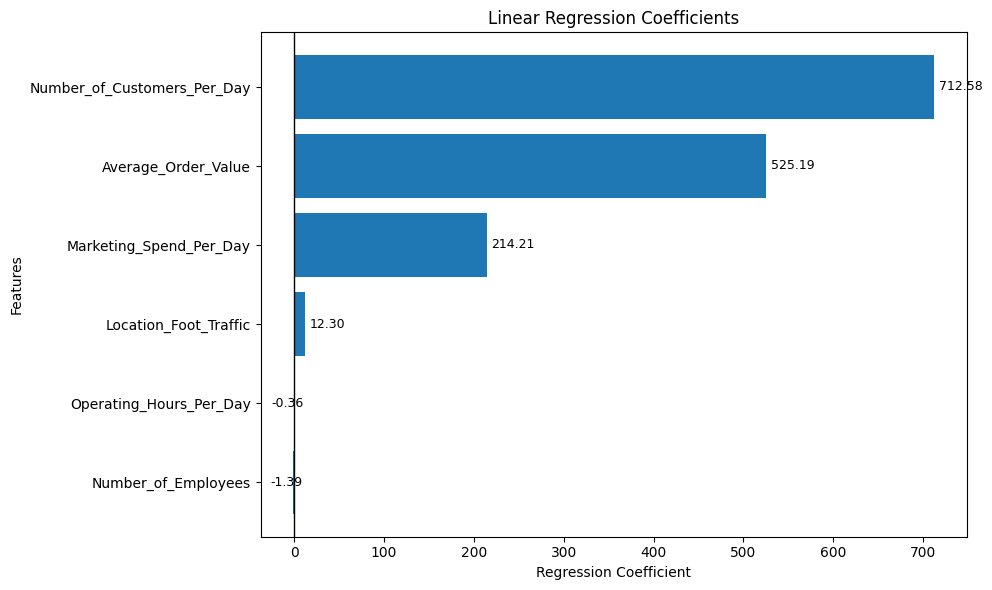

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

weight = np.array(model.w)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": weight
})

# Sắp xếp theo giá trị hệ số
coef_df = coef_df.sort_values(by="Coefficient")

plt.figure(figsize=(10,6))

bars = plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Regression Coefficient")
plt.ylabel("Features")
plt.title("Linear Regression Coefficients")

# Hiển thị giá trị trên từng cột
for bar in bars:
    width = bar.get_width()

    if width >= 0:
        plt.text(
            width + 5,
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}",
            va="center",
            fontsize=9
        )
    else:
        plt.text(
            width - 25,
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}",
            va="center",
            fontsize=9
        )

plt.tight_layout()

# Lưu ảnh chất lượng cao
plt.savefig(
    "regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

10. KIỂM TRA PHẦN DƯ (RESIDUAL)

In [32]:
residual = y_test - y_pred
print(residual[:10])

1600    301.160096
1601    247.655480
1602    -88.866657
1603     -7.839337
1604   -266.637535
1605     72.557733
1606    369.240800
1607    184.243950
1608   -388.646427
1609   -203.361024
dtype: float64


In [33]:
print(np.mean(residual))

1.7982500267669945


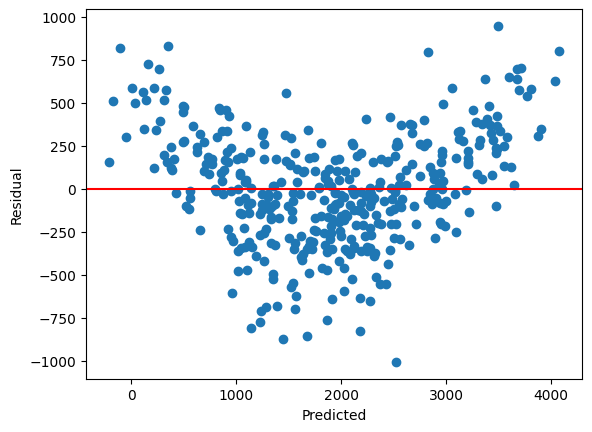

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residual)

plt.axhline(0,color="red")

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.show()

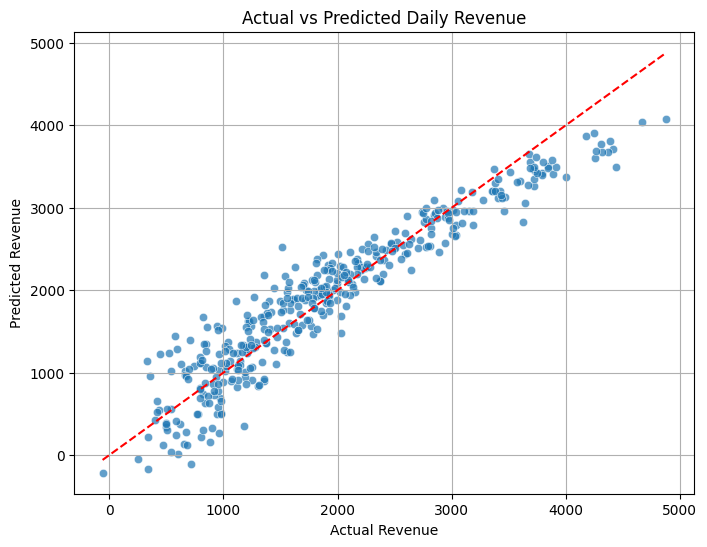

In [35]:
# Scatter plot of actual vs predicted revenue
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")  # Ideal line
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Daily Revenue")
plt.grid(True)
plt.show()

In [36]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/linear_model.pkl")
joblib.dump(normalizer, "models/normalizer.pkl")

['models/normalizer.pkl']